In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/navneet0094/jafee-da/README_FIRST.txt
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/NM.SA1.98.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/YM.SA3.57.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/KA.DI3.44.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/KM.AN2.18.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/MK.HA3.118.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/NM.FE2.111.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/TM.HA1.180.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/UY.FE2.153.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/UY.DI3.151.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/YM.NE2.50.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/TM.SU3.189.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/MK.NE3.115.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/MK.SA3.121.tiff
/kaggle/input/datasets/navneet0094/jafee-da/jaffe/NM.HA3.97.tiff
/kaggle/input/dataset

In [22]:
import os
import cv2
import numpy as np
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [23]:
import os, cv2, numpy as np

ck_data = []
ck_labels = []

ck_path = "/kaggle/input/datasets/shawon10/ckplus/CK+48"

emotion_names = sorted(os.listdir(ck_path))  

for label, emotion in enumerate(emotion_names):
    emotion_path = os.path.join(ck_path, emotion)

    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
            
        img = cv2.resize(img, (48,48))

        ck_data.append(img)
        ck_labels.append(label)

ck_data = np.array(ck_data)
ck_labels = np.array(ck_labels)

print("CK+:", ck_data.shape)
print("Labels:", np.unique(ck_labels))

CK+: (981, 48, 48)
Labels: [0 1 2 3 4 5 6]


In [24]:
from PIL import Image

jaffe_data = []
jaffe_labels = []

emotion_map = {
    'AN':0, 'DI':1, 'FE':2,
    'HA':3, 'SA':4, 'SU':5, 'NE':6
}

jaffe_path = "/kaggle/input/datasets/navneet0094/jafee-da/jaffe"

for img_name in os.listdir(jaffe_path):
    img_path = os.path.join(jaffe_path, img_name)

    try:
        img = Image.open(img_path).convert('L')
        img = img.resize((48,48))
        img = np.array(img)

        emotion = img_name.split('.')[1][:2]
        label = emotion_map[emotion]

        jaffe_data.append(img)
        jaffe_labels.append(label)

    except:
        continue

jaffe_data = np.array(jaffe_data)
jaffe_labels = np.array(jaffe_labels)

print("JAFFE:", jaffe_data.shape)

JAFFE: (213, 48, 48)


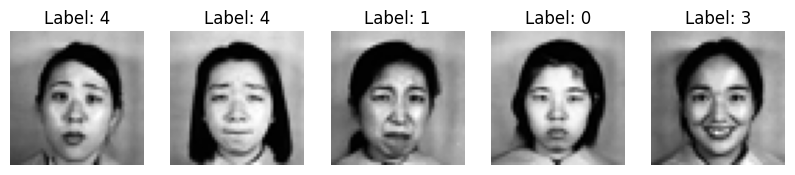

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(jaffe_data[i], cmap='gray')
    plt.title(f"Label: {jaffe_labels[i]}")
    plt.axis('off')

plt.show()

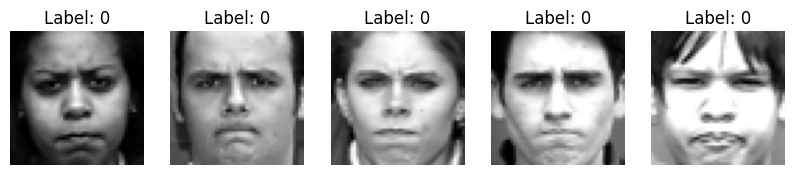

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(ck_data[i], cmap='gray')
    plt.title(f"Label: {ck_labels[i]}")
    plt.axis('off')

plt.show()

In [27]:
from skimage.feature import hog

def extract_hog(images):
    return np.array([
        hog(img,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2))
        for img in images
    ])

X_ck_hog = extract_hog(ck_data)
X_jaffe_hog = extract_hog(jaffe_data)

print("CK+ HOG:", X_ck_hog.shape)
print("JAFFE HOG:", X_jaffe_hog.shape)

CK+ HOG: (981, 900)
JAFFE HOG: (213, 900)


In [28]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


In [30]:

percentages = [0.3, 0.5, 0.8]
results = []

for p in percentages:
    
    # Spliting JAFFE
    X_j_train, X_j_test, y_j_train, y_j_test = train_test_split(
        X_jaffe_hog,
        jaffe_labels,
        test_size=1-p,
        random_state=42,
        stratify=jaffe_labels
    )
    
    # Combining with CK+
    X_train = np.concatenate([X_ck_hog, X_j_train])
    y_train = np.concatenate([ck_labels, y_j_train])
    
    # Model
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', LinearSVC(max_iter=5000))
    ])
    
    model.fit(X_train, y_train)
    
    # Test on unseen JAFFE
    y_pred = model.predict(X_j_test)
    
    acc = accuracy_score(y_j_test, y_pred)
    results.append(acc)
    
    print(f"{int(p*100)}% JAFFE → Accuracy:", acc)

30% JAFFE → Accuracy: 0.34
50% JAFFE → Accuracy: 0.4766355140186916
80% JAFFE → Accuracy: 0.5813953488372093


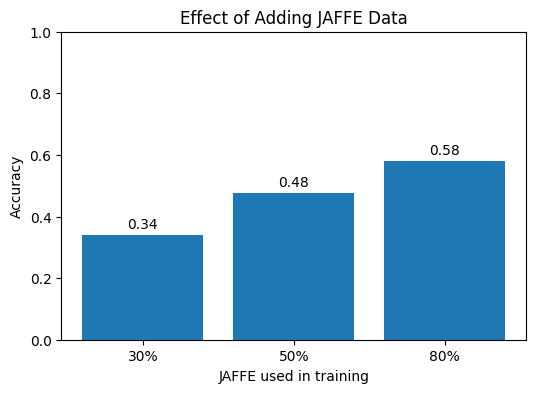

In [31]:
import matplotlib.pyplot as plt

labels = ['30%', '50%', '80%']

plt.figure(figsize=(6,4))
bars = plt.bar(labels, results)

plt.ylim(0,1)
plt.title("Effect of Adding JAFFE Data")
plt.xlabel("JAFFE used in training")
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             yval + 0.02,
             f"{yval:.2f}",
             ha='center')

plt.show()

In [32]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess


# Load pretrained model (feature extractor)
mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

# VGG
vgg = VGG16(weights='imagenet', include_top=False, pooling='avg')

/tmp/ipykernel_55/407109203.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


In [33]:
import cv2
import numpy as np

def extract_cnn_features(images, model):
    features = []
    
    for img in images:
        img = cv2.resize(img, (224,224))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = preprocess_input(img)
        
        img = np.expand_dims(img, axis=0)
        
        feat = model.predict(img, verbose=0)
        features.append(feat.flatten())
    
    return np.array(features)

In [34]:
def extract_vgg_features(images, model):
    features = []
    
    for img in images:
        img = cv2.resize(img, (224,224))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = vgg_preprocess(img)
        
        img = np.expand_dims(img, axis=0)
        feat = model.predict(img, verbose=0)
        
        features.append(feat.flatten())
    
    return np.array(features)

In [35]:
# MobileNet features
X_ck_cnn = extract_cnn_features(ck_data, mobilenet)
X_jaffe_cnn = extract_cnn_features(jaffe_data, mobilenet)

# VGG features
X_ck_vgg = extract_vgg_features(ck_data, vgg)
X_jaffe_vgg = extract_vgg_features(jaffe_data, vgg)

# Hybrid CNN (VGG + MobileNet)
X_ck_hybrid = np.concatenate([X_ck_cnn, X_ck_vgg], axis=1)
X_jaffe_hybrid = np.concatenate([X_jaffe_cnn, X_jaffe_vgg], axis=1)

print("MobileNet:", X_ck_cnn.shape)
print("VGG:", X_ck_vgg.shape)
print("Hybrid:", X_ck_hybrid.shape)

I0000 00:00:1777368780.175520     175 service.cc:152] XLA service 0x7b9ba4002940 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777368780.175570     175 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777368780.175574     175 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777368780.797920     175 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-28 09:33:08.924248: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 09:33:09.077600: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-28 09:33:09.211695: E external/local_xl

MobileNet: (981, 1280)
VGG: (981, 512)
Hybrid: (981, 1792)


In [36]:
def run_model(X_ck, X_jaffe, name):
    
    percentages = [0.3, 0.5, 0.8]
    results = []
    
    for p in percentages:
        
        X_j_train, X_j_test, y_j_train, y_j_test = train_test_split(
            X_jaffe,
            jaffe_labels,
            test_size=1-p,
            random_state=42,
            stratify=jaffe_labels
        )
        
        X_train = np.concatenate([X_ck, X_j_train])
        y_train = np.concatenate([ck_labels, y_j_train])
        
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', LinearSVC(max_iter=5000))
        ])
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_j_test)
        
        acc = accuracy_score(y_j_test, y_pred)
        results.append(acc)
        
        print(f"{name} {int(p*100)}% → {acc:.3f}")
    
    return results

In [37]:
results_cnn = run_model(X_ck_cnn, X_jaffe_cnn, "MobileNet")
results_vgg = run_model(X_ck_vgg, X_jaffe_vgg, "VGG")
results_hybrid = run_model(X_ck_hybrid, X_jaffe_hybrid, "Hybrid CNN")

MobileNet 30% → 0.420
MobileNet 50% → 0.570
MobileNet 80% → 0.651
VGG 30% → 0.373
VGG 50% → 0.598
VGG 80% → 0.674
Hybrid CNN 30% → 0.447
Hybrid CNN 50% → 0.701
Hybrid CNN 80% → 0.698


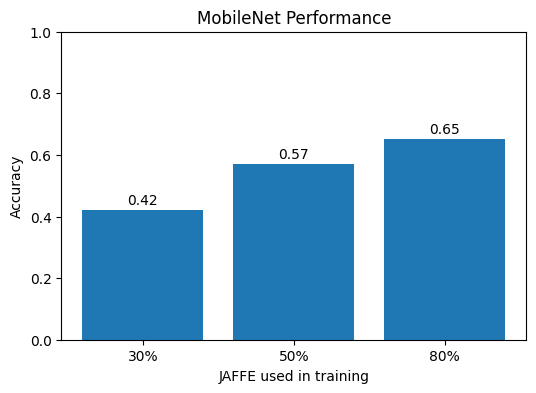

In [38]:
labels = ['30%', '50%', '80%']

plt.figure(figsize=(6,4))
bars = plt.bar(labels, results_cnn)

plt.ylim(0,1)
plt.title("MobileNet Performance")
plt.xlabel("JAFFE used in training")
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.02, f"{yval:.2f}", ha='center')

plt.show()

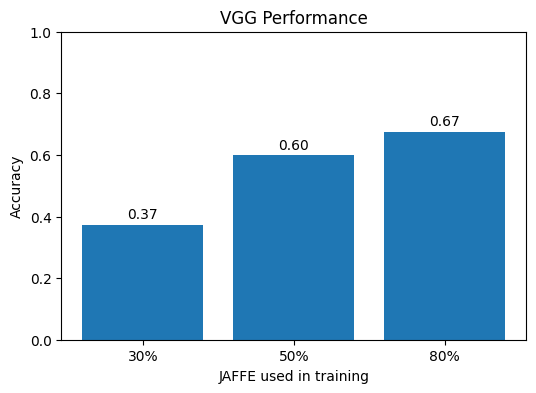

In [39]:
plt.figure(figsize=(6,4))
bars = plt.bar(labels, results_vgg)

plt.ylim(0,1)
plt.title("VGG Performance")
plt.xlabel("JAFFE used in training")
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.02, f"{yval:.2f}", ha='center')

plt.show()

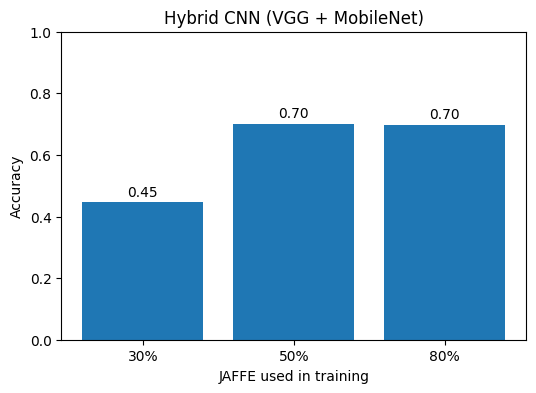

In [40]:
plt.figure(figsize=(6,4))
bars = plt.bar(labels, results_hybrid)

plt.ylim(0,1)
plt.title("Hybrid CNN (VGG + MobileNet)")
plt.xlabel("JAFFE used in training")
plt.ylabel("Accuracy")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.02, f"{yval:.2f}", ha='center')

plt.show()

In [65]:
# # choose best model (example: hybrid)
# X_ck_best = X_ck_hybrid
# X_jaffe_best = X_jaffe_hybrid

# X_j_train, X_j_test, y_j_train, y_j_test = train_test_split(
#     X_jaffe_best, jaffe_labels,
#     test_size=0.2, stratify=jaffe_labels, random_state=42)

# X_train = np.concatenate([X_ck_best, X_j_train])
# y_train = np.concatenate([ck_labels, y_j_train])

# model = Pipeline([
#     ('scaler', StandardScaler()),
#     ('svm', LinearSVC(max_iter=5000))
# ])

# model.fit(X_train, y_train)
# y_pred = model.predict(X_j_test)

# cm = confusion_matrix(y_j_test, y_pred)

# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.title("Confusion Matrix (Best Model)")
# plt.show()

In [54]:
X_ck_hog_cnn = np.concatenate([X_ck_hog, X_ck_cnn], axis=1)
X_jaffe_hog_cnn = np.concatenate([X_jaffe_hog, X_jaffe_cnn], axis=1)

X_ck_hog_vgg = np.concatenate([X_ck_hog, X_ck_vgg], axis=1)
X_jaffe_hog_vgg = np.concatenate([X_jaffe_hog, X_jaffe_vgg], axis=1)

X_ck_hog_hybrid = np.concatenate([X_ck_hog, X_ck_hybrid], axis=1)
X_jaffe_hog_hybrid = np.concatenate([X_jaffe_hog, X_jaffe_hybrid], axis=1)

In [55]:
results_hog_cnn = run_model(X_ck_hog_cnn, X_jaffe_hog_cnn, "HOG+CNN")
results_hog_vgg = run_model(X_ck_hog_vgg, X_jaffe_hog_vgg, "HOG+VGG")
results_hog_hybrid = run_model(X_ck_hog_hybrid, X_jaffe_hog_hybrid, "HOG+Hybrid")

HOG+CNN 30% → 0.480
HOG+CNN 50% → 0.645
HOG+CNN 80% → 0.698
HOG+VGG 30% → 0.420
HOG+VGG 50% → 0.636
HOG+VGG 80% → 0.791
HOG+Hybrid 30% → 0.500
HOG+Hybrid 50% → 0.682
HOG+Hybrid 80% → 0.698


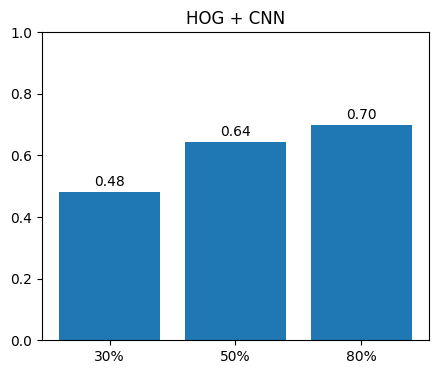

In [58]:
plt.figure(figsize=(5,4))
bars = plt.bar(labels, results_hog_cnn)

plt.title("HOG + CNN")
plt.ylim(0,1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.02, f"{yval:.2f}", ha='center')

plt.show()

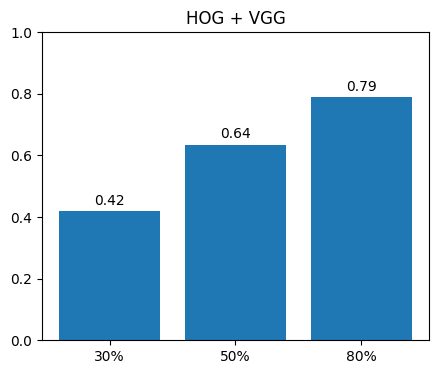

In [59]:
plt.figure(figsize=(5,4))
bars = plt.bar(labels, results_hog_vgg)

plt.title("HOG + VGG")
plt.ylim(0,1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.02, f"{yval:.2f}", ha='center')

plt.show()

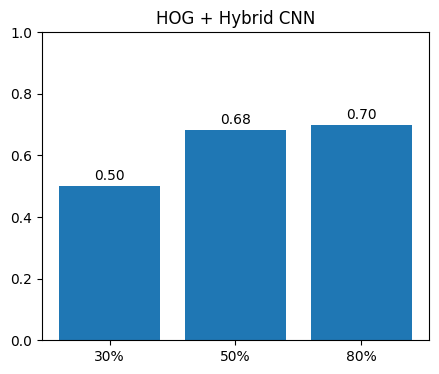

In [60]:
plt.figure(figsize=(5,4))
bars = plt.bar(labels, results_hog_hybrid)

plt.title("HOG + Hybrid CNN")
plt.ylim(0,1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.02, f"{yval:.2f}", ha='center')

plt.show()

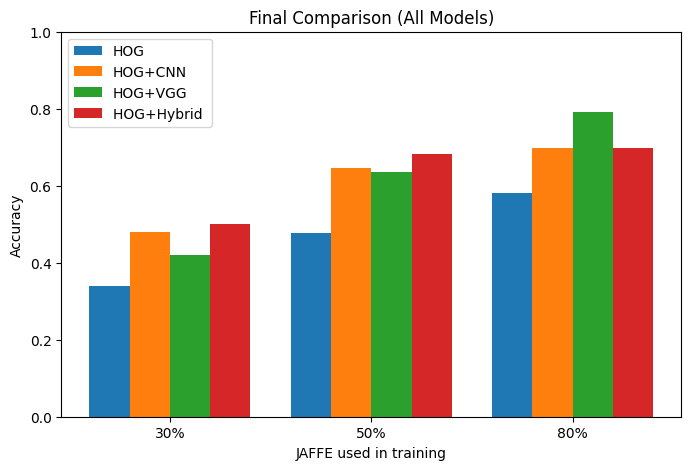

In [64]:
x = np.arange(len(labels))

plt.figure(figsize=(8,5))

plt.bar(x - 0.3, results, width=0.2, label='HOG')
plt.bar(x - 0.1, results_hog_cnn, width=0.2, label='HOG+CNN')
plt.bar(x + 0.1, results_hog_vgg, width=0.2, label='HOG+VGG')
plt.bar(x + 0.3, results_hog_hybrid, width=0.2, label='HOG+Hybrid ')

plt.xticks(x, labels)
plt.ylim(0,1)

plt.title("Final Comparison (All Models)")
plt.xlabel("JAFFE used in training")
plt.ylabel("Accuracy")
plt.legend()

plt.show()